In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


path to the script and data file

In [ ]:
cd /content/drive/MyDrive/t2dm/results/homabcpep/data_plot

/content/drive/MyDrive/t2dm/results/homabcpep/data_plot


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.gridspec as gridspec

In [ ]:
combined = pd.read_csv('AIG_Forest_ROC_Data.csv')

# **AUC_ROC**

In [ ]:
control0 = combined.iloc[175:]
prediabetes0 = combined.iloc[:175]

In [ ]:
control0['mnisr'] = (control0['First Phase ISR'] + control0['Second Phase ISR']) / 2
prediabetes0['mnisr'] = (prediabetes0['First Phase ISR'] + prediabetes0['Second Phase ISR']) / 2

prediabetes0['cpep_predict'] = (prediabetes0['C-Peptide Index'] > 0.145).astype(int)
prediabetes0['isi_true'] = (prediabetes0['ISI (M/I) (mg/kg/min/uU/ml)'] < control0['ISI (M/I) (mg/kg/min/uU/ml)'].median()).astype(int)
prediabetes0['mnisr_true'] = (prediabetes0['mnisr'] > control0['mnisr'].median()).astype(int)

prediabetes0['1stisr_true'] = (prediabetes0['First Phase ISR'] > control0['First Phase ISR'].median()).astype(int)
prediabetes0['2ndisr_true'] = (prediabetes0['Second Phase ISR'] > control0['Second Phase ISR'].median()).astype(int)

prediabetes0['homair_true'] = (prediabetes0['HOMA-IR'] > control0['HOMA-IR'].median()).astype(int)
prediabetes0['homab_true'] = (prediabetes0['HOMA B%'] > control0['HOMA B%'].median()).astype(int)

/tmp/ipykernel_1898/2863555380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control0['mnisr'] = (control0['First Phase ISR'] + control0['Second Phase ISR']) / 2
/tmp/ipykernel_1898/2863555380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediabetes0['mnisr'] = (prediabetes0['First Phase ISR'] + prediabetes0['Second Phase ISR']) / 2
/tmp/ipykernel_1898/2863555380.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [ ]:
prediabetes0['isi_mnisr_true'] = 0
prediabetes0['isi_1stisr_true'] = 0
prediabetes0['isi_2ndisr_true'] = 0
prediabetes0['homair_homab_true'] = 0

prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['mnisr_true'] == 1), 'isi_mnisr_true'] = 1
prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['mnisr_true'] == 0), 'isi_mnisr_true'] = 2
prediabetes0.loc[(prediabetes0['isi_true'] == 0) & (prediabetes0['mnisr_true'] == 1), 'isi_mnisr_true'] = 3
prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['1stisr_true'] == 1), 'isi_1stisr_true'] = 1
prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['1stisr_true'] == 0), 'isi_1stisr_true'] = 2
prediabetes0.loc[(prediabetes0['isi_true'] == 0) & (prediabetes0['1stisr_true'] == 1), 'isi_1stisr_true'] = 3
prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['2ndisr_true'] == 1), 'isi_2ndisr_true'] = 1
prediabetes0.loc[(prediabetes0['isi_true'] == 1) & (prediabetes0['2ndisr_true'] == 0), 'isi_2ndisr_true'] = 2
prediabetes0.loc[(prediabetes0['isi_true'] == 0) & (prediabetes0['2ndisr_true'] == 1), 'isi_2ndisr_true'] = 3
prediabetes0.loc[(prediabetes0['homair_true'] == 1) & (prediabetes0['homab_true'] == 1), 'homair_homab_true'] = 1
prediabetes0.loc[(prediabetes0['homair_true'] == 1) & (prediabetes0['homab_true'] == 0), 'homair_homab_true'] = 2
prediabetes0.loc[(prediabetes0['homair_true'] == 0) & (prediabetes0['homab_true'] == 1), 'homair_homab_true'] = 3

/tmp/ipykernel_1898/1262013476.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediabetes0['isi_mnisr_true'] = 0
/tmp/ipykernel_1898/1262013476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediabetes0['isi_1stisr_true'] = 0
/tmp/ipykernel_1898/1262013476.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

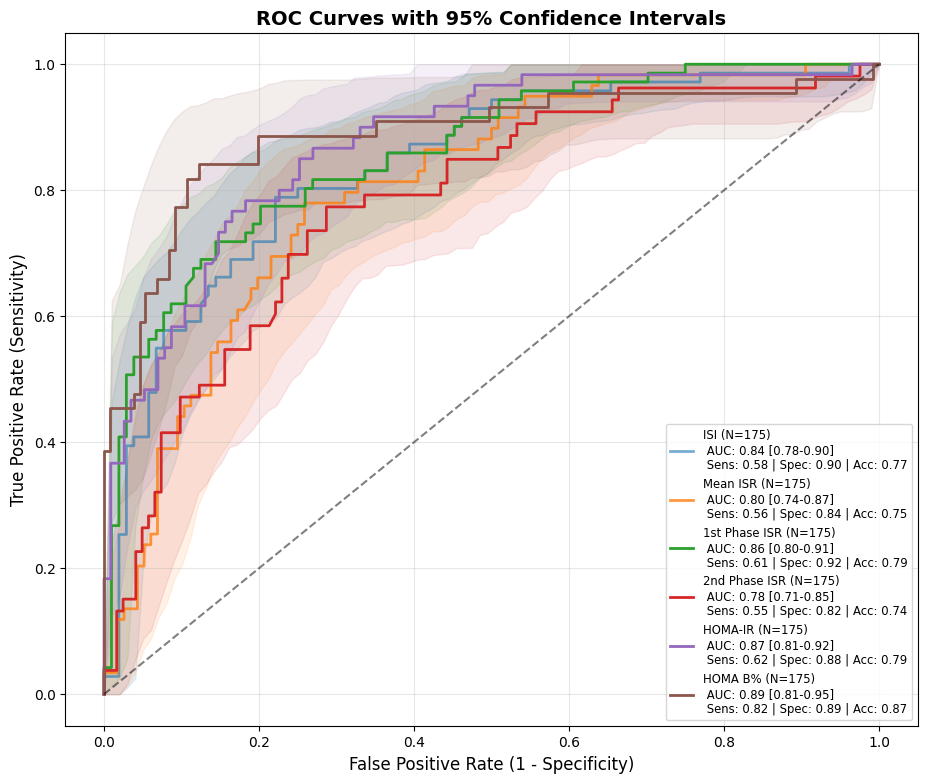

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from sklearn.utils import resample

plt.figure(figsize=(11, 9))
mean_fpr = np.linspace(0, 1, 100)

variables = ['isi_true', 'mnisr_true', '1stisr_true', '2ndisr_true', 'homair_true', 'homab_true']

display_names = {
    'isi_true' : 'ISI',
    'mnisr_true' : 'Mean ISR',
    '1stisr_true': '1st Phase ISR',
    '2ndisr_true' : '2nd Phase ISR',
    'isi_mnisr_true' : 'ISI-Mean ISR',
    'homair_true' : 'HOMA-IR',
    'homab_true' : 'HOMA B%'
}

line_styles = {
    'isi_true': {'lw': 2.0, 'alpha': 0.6, 'ls': '-'},
    'mnisr_true': {'lw': 2.0, 'alpha': 0.8, 'ls': '-'},
    '1stisr_true': {'lw': 2.0, 'alpha': 1.0, 'ls': '-'},
    '2ndisr_true': {'lw': 2.0, 'alpha': 1.0, 'ls': '-'},
    'homair_true': {'lw': 2.0, 'alpha': 1.0, 'ls': '-'},
    'homab_true': {'lw': 2.0, 'alpha': 1.0, 'ls': '-'}
}

for i in variables:
    df_source = prediabetes0[prediabetes0[i].isin([0, 1])].dropna(subset=[i, 'cpep_predict', 'C-Peptide Index'])

    n_size = len(df_source)


    tn, fp, fn, tp = confusion_matrix(df_source[i], df_source['cpep_predict']).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = accuracy_score(df_source[i], df_source['cpep_predict'])

    fpr, tpr, _ = roc_curve(df_source[i], df_source['C-Peptide Index'])
    auc_score = roc_auc_score(df_source[i], df_source['C-Peptide Index'])


    n_bootstraps = 1000
    bootstrapped_tprs = []
    bootstrapped_aucs = []

    np.random.seed(42)

    for j in range(n_bootstraps):
        indices = resample(np.arange(n_size))

        if len(np.unique(df_source[i].iloc[indices])) < 2:
            continue

        boot_fpr, boot_tpr, _ = roc_curve(df_source[i].iloc[indices], df_source['C-Peptide Index'].iloc[indices])
        boot_auc = roc_auc_score(df_source[i].iloc[indices], df_source['C-Peptide Index'].iloc[indices])

        interp_tpr = np.interp(mean_fpr, boot_fpr, boot_tpr)
        interp_tpr[0] = 0.0

        bootstrapped_tprs.append(interp_tpr)
        bootstrapped_aucs.append(boot_auc)


    tprs_array = np.array(bootstrapped_tprs)
    tpr_lower = np.percentile(tprs_array, 2.5, axis=0)
    tpr_upper = np.percentile(tprs_array, 97.5, axis=0)

    auc_lower = np.percentile(bootstrapped_aucs, 2.5)
    auc_upper = np.percentile(bootstrapped_aucs, 97.5)

    style = line_styles[i]
    line_label = (f'{display_names[i]} (N={n_size})\n'
                  f' AUC: {auc_score:.2f} [{auc_lower:.2f}-{auc_upper:.2f}]\n'
                  f' Sens: {sensitivity:.2f} | Spec: {specificity:.2f} | Acc: {accuracy:.2f}')

    line, = plt.plot(fpr, tpr, label=line_label, lw=style['lw'], alpha=style['alpha'], linestyle=style['ls'])
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color=line.get_color(), alpha=0.10)


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves with 95% Confidence Intervals', fontsize=14, fontweight='bold')

plt.legend(loc='lower right', fontsize='small', frameon=True, bbox_to_anchor=(1, 0))
plt.grid(alpha=0.3)

plt.savefig("combined_auc_plt0.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

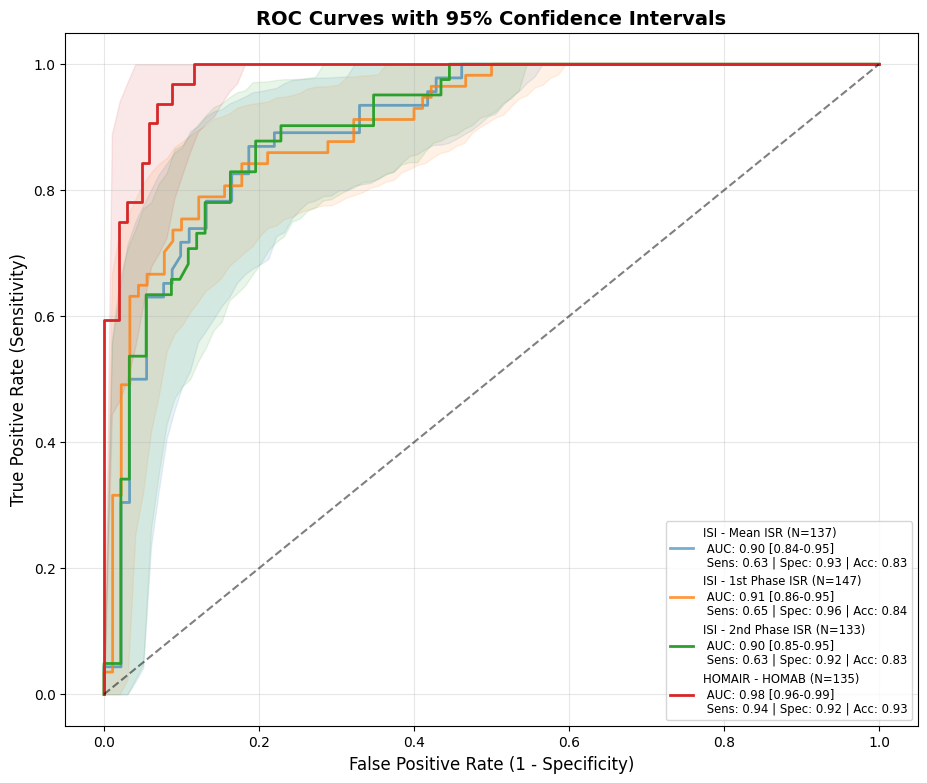

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from sklearn.utils import resample

plt.figure(figsize=(11, 9))
mean_fpr = np.linspace(0, 1, 100)

variables = ['isi_mnisr_true', 'isi_1stisr_true', 'isi_2ndisr_true', 'homair_homab_true']

display_names = {
    'isi_mnisr_true' : 'ISI - Mean ISR',
    'isi_1stisr_true' : 'ISI - 1st Phase ISR',
    'isi_2ndisr_true' : 'ISI - 2nd Phase ISR',
    'homair_homab_true' : 'HOMAIR - HOMAB'}

line_styles = {
    'isi_mnisr_true' : {'lw': 2.0, 'alpha': 0.6, 'ls': '-'},
    'isi_1stisr_true' : {'lw': 2.0, 'alpha': 0.8, 'ls': '-'},
    'isi_2ndisr_true': {'lw': 2.0, 'alpha': 1.0, 'ls': '-'},
    'homair_homab_true' : {'lw': 2.0, 'alpha': 1.0, 'ls': '-'}
}

for i in variables:

    df_source = prediabetes0[prediabetes0[i].isin([0, 1])].dropna(subset=[i, 'cpep_predict', 'C-Peptide Index'])

    n_size = len(df_source)


    tn, fp, fn, tp = confusion_matrix(df_source[i], df_source['cpep_predict']).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = accuracy_score(df_source[i], df_source['cpep_predict'])

    fpr, tpr, _ = roc_curve(df_source[i], df_source['C-Peptide Index'])
    auc_score = roc_auc_score(df_source[i], df_source['C-Peptide Index'])


    n_bootstraps = 1000
    bootstrapped_tprs = []
    bootstrapped_aucs = []

    np.random.seed(42)

    for j in range(n_bootstraps):
        indices = resample(np.arange(n_size))

        if len(np.unique(df_source[i].iloc[indices])) < 2:
            continue

        boot_fpr, boot_tpr, _ = roc_curve(df_source[i].iloc[indices], df_source['C-Peptide Index'].iloc[indices])
        boot_auc = roc_auc_score(df_source[i].iloc[indices], df_source['C-Peptide Index'].iloc[indices])

        interp_tpr = np.interp(mean_fpr, boot_fpr, boot_tpr)
        interp_tpr[0] = 0.0

        bootstrapped_tprs.append(interp_tpr)
        bootstrapped_aucs.append(boot_auc)


    tprs_array = np.array(bootstrapped_tprs)
    tpr_lower = np.percentile(tprs_array, 2.5, axis=0)
    tpr_upper = np.percentile(tprs_array, 97.5, axis=0)

    auc_lower = np.percentile(bootstrapped_aucs, 2.5)
    auc_upper = np.percentile(bootstrapped_aucs, 97.5)

    style = line_styles[i]
    line_label = (f'{display_names[i]} (N={n_size})\n'
                  f' AUC: {auc_score:.2f} [{auc_lower:.2f}-{auc_upper:.2f}]\n'
                  f' Sens: {sensitivity:.2f} | Spec: {specificity:.2f} | Acc: {accuracy:.2f}')

    line, = plt.plot(fpr, tpr, label=line_label, lw=style['lw'], alpha=style['alpha'], linestyle=style['ls'])
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color=line.get_color(), alpha=0.10)


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves with 95% Confidence Intervals', fontsize=14, fontweight='bold')

plt.legend(loc='lower right', fontsize='small', frameon=True, bbox_to_anchor=(1, 0))
plt.grid(alpha=0.3)

plt.savefig("combined_auc_plt1.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()